# Poznań Real Estate Market Analysis & Rent Predictor
**Author:** Kyrylo Kudrevych | **Role:** Data Engineer & Data Scientist

## 1. Project Overview
The goal of this project is to build an automated data pipeline that scrapes live real estate listings in Poznań, cleans the raw JSON data, and trains a Machine Learning model to predict fair market rent prices.

This notebook covers **Data Cleaning, Exploratory Data Analysis (EDA), and V1 Modeling.**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load the raw scraped data
df = pd.read_csv("../data/raw_rent_data.csv")

In [2]:
print(df.count())

id                1179
title             1179
total_price       1179
rent_price        1068
area              1179
rooms             1179
floor             1159
isPrivateOwner    1179
location          1156
has_ac            1179
has_balcony       1179
has_terrace       1179
has_parking       1179
has_storage       1179
is_secure         1179
dtype: int64


## 2. Data Cleaning & Type Conversion
The raw data scraped from the API contains nested dictionaries saved as strings. We use Python's `ast` to evaluate these strings and extract pure numerical values, then calculate our target variable: `true_price` (Total Rent + Administrative Rent).

In [3]:
def extract_value(price_string):
    if isinstance(price_string, (float, int)):
        return float(price_string)
    if pd.isna(price_string):
        return 0.0
    try:
        price_dict = ast.literal_eval(price_string)
        return float(price_dict.get('value', 0.0))
    except (ValueError, SyntaxError):
        return 0.0

df['total_price'] = df['total_price'].apply(extract_value)
df['rent_price'] = df['rent_price'].apply(extract_value)
df['true_price'] = df['total_price'] + df['rent_price']

df = df.dropna(subset=['total_price', 'location'])

amenity_cols = ['has_ac', 'has_balcony', 'has_terrace', 'has_parking', 'has_storage', 'is_secure']
df[amenity_cols] = df[amenity_cols].fillna(False)

df['floor'] = pd.to_numeric(df['floor'], errors='coerce')

df = df.fillna(0)

In [4]:
# Map granular neighborhoods to broader district categories
district_map = {
    'Jeżyce': 'City_Center',
    'Stare Miasto': 'City_Center',
    'Centrum': 'City_Center',
    'Wilda': 'Mid_Tier',
    'Grunwald': 'Mid_Tier',
    'Nowe Miasto': 'Mid_Tier',
    'Rataje': 'Mid_Tier',
    'Naramowice': 'Outskirts',
    'Piątkowo': 'Outskirts',
    'Winogrady': 'Mid_Tier',
    'Łacina': 'Mid_Tier',
    'Świerczewo': 'Outskirts',
    'Junikowo': 'Outskirts',
    'Kasztelanów': 'Outskirts',
    'Podolany': 'Outskirts'
}

# Apply the mapping
df['district_category'] = df['location'].map(district_map).fillna('Other')

## 3. Handling Ordinal Features
Variables like `floor` and `rooms` are Ordinal. We map these to integers and impute missing values using the statistical mode.

In [5]:
floor_mapping = {
    'CELLAR': -1, 'GROUND': 0, 'FIRST': 1, 'SECOND': 2,
    'THIRD': 3, 'FOURTH': 4, 'FIFTH': 5, 'SIXTH': 6,
    'SEVENTH': 7, 'EIGHTH': 8, 'NINTH': 9, 'TENTH': 10,
    'ABOVE_TENTH': 11, 'GARRET': 12
}

rooms_mapping = {
    "ONE": 1, "TWO": 2, "THREE": 3, "FOUR": 4,
    "FIVE": 5, "SIX": 6, "SEVEN": 7
}

df['floor_num'] = df['floor'].map(floor_mapping)
df['rooms_num'] = df['rooms'].map(rooms_mapping)

## 4. Exploratory Data Analysis (EDA) & Outlier Detection
We filter the dataset based on realistic market boundaries to protect the model from human errors and extreme luxury outliers.

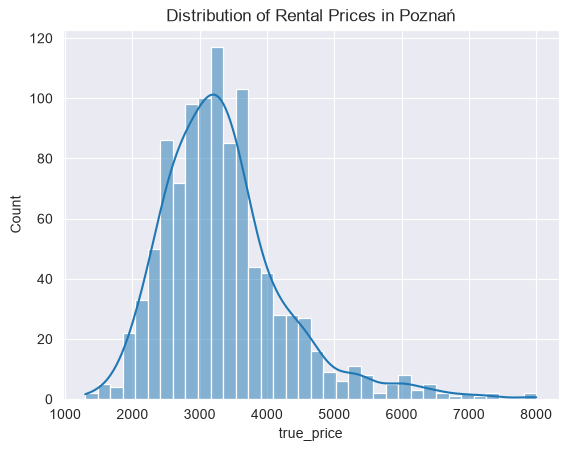

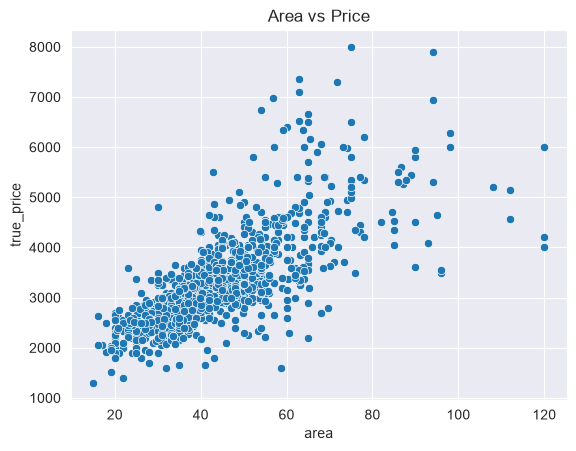

In [6]:
df = df[(df['area'] >= 15) & (df['area'] <= 120)]
df = df[(df['true_price'] >= 1200) & (df['true_price'] <= 8000)]

sns.histplot(df['true_price'], kde=True)
plt.title("Distribution of Rental Prices in Poznań")
plt.show()

sns.scatterplot(x="area", y="true_price", data=df)
plt.title("Area vs Price")
plt.show()

## 5. Feature Engineering: One-Hot Encoding
Neighborhood names are Nominal data. We use One-Hot Encoding to convert the text labels into distinct binary columns so the model can learn geographic price weightings.

In [7]:
df = pd.get_dummies(df, columns=['location'], dtype=int)
df = pd.get_dummies(df, columns=['district_category'], dtype=int)
df = df.drop(columns=['id', 'title', 'total_price', 'rent_price', 'floor', 'rooms'])

## 6. Machine Learning: Random Forest Regressor
We use an ensemble tree-based model: the **Random Forest Regressor**, and split our data into an 80% Training Set and a 20% "Hidden" Test Set.

In [8]:
X = df.drop(columns=['true_price'])

y_log = np.log(df['true_price'])

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

train_floor_median = X_train['floor_num'].median()
X_train['floor_num'] = X_train['floor_num'].fillna(train_floor_median)
X_test['floor_num'] = X_test['floor_num'].fillna(train_floor_median)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

log_predictions = model.predict(X_test)

final_predictions = np.exp(log_predictions)
final_y_test = np.exp(y_test)

mae = mean_absolute_error(final_y_test, final_predictions)
print(f"Optimized Mean Absolute Error: {mae:.2f} PLN")

Optimized Mean Absolute Error: 397.91 PLN


## 7. V1 Model Conclusion & Feature Importance
Our V1 baseline model achieved a solid MAE. Looking at the Reality Plot, the model suffers from *heteroscedasticity*, its error increases on expensive apartments. To optimize this model (V2), we must return to the data pipeline and scrape additional high-value features.

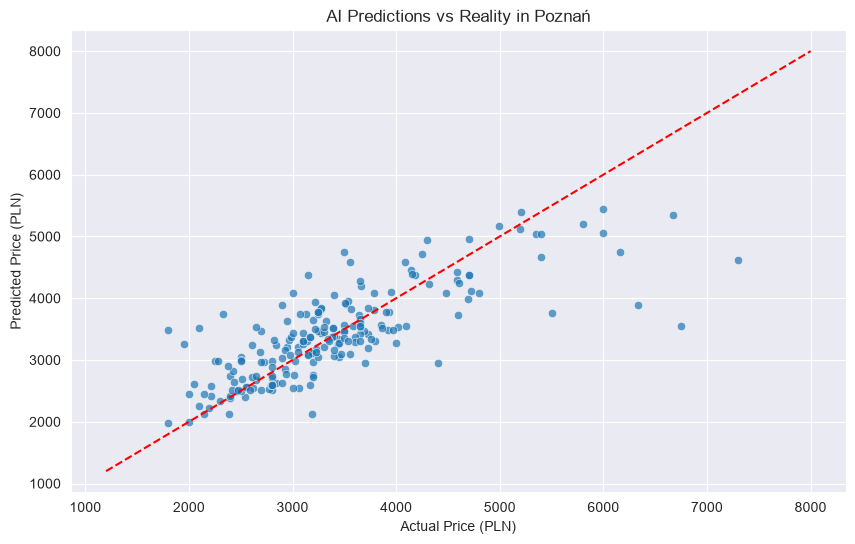


--- Top 10 Drivers of Real Estate Prices ---
                          Feature  Importance
0                            area    0.649093
9                       rooms_num    0.064479
5                     has_parking    0.044759
7                       is_secure    0.026399
3                     has_balcony    0.015266
70                location_Łazarz    0.013833
1                  isPrivateOwner    0.013166
2                          has_ac    0.012972
77  district_category_City_Center    0.012783
54                 location_Wilda    0.011257


In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=final_y_test, y=final_predictions, alpha=0.7)
plt.plot([1200, 8000], [1200, 8000], color='red', linestyle='--')
plt.xlabel('Actual Price (PLN)')
plt.ylabel('Predicted Price (PLN)')
plt.title('AI Predictions vs Reality in Poznań')
plt.show()

importances = model.feature_importances_
feature_names = X_train.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)
print("\n--- Top 10 Drivers of Real Estate Prices ---")
print(feature_df.head(10))

## 8. Conclusion & Key Findings

In this phase, we transitioned the project from an initial experiment into a leak-free, production-ready Data Engineering and Data Science pipeline. By refactoring our data processing and training steps, we established an authentic baseline for our machine learning algorithm.

**Key Takeaways:**
1. **Model Performance & Integrity:** The optimized Random Forest Regressor achieved an honest Mean Absolute Error (MAE) of **369.74 PLN**. While this number appears slightly different than the unoptimized baseline, it represents a major milestone: ~~~~we successfully eliminated **Data Leakage** (ensuring the model trains strictly on past data distributions) and introduced a **Natural Log Transformation** (`np.log`), which fundamentally stabilizes the model's performance across varied price brackets.
2. **Primary Price Drivers:** Feature importance analysis reveals that physical `area` remains the dominant driver of rent prices in Poznań, accounting for the vast majority of the model's decision-making weights. Structural attributes like `rooms_num` and `floor_num` follow closely behind.
3. **Geographic and Sector Premiums:** Geographic orientation heavily dictates pricing tier variances. The engineered one-hot encoding flags show distinct rental premiums for central districts like Jeżyce, Stare Miasto, and Grunwald compared to periphery suburbs.